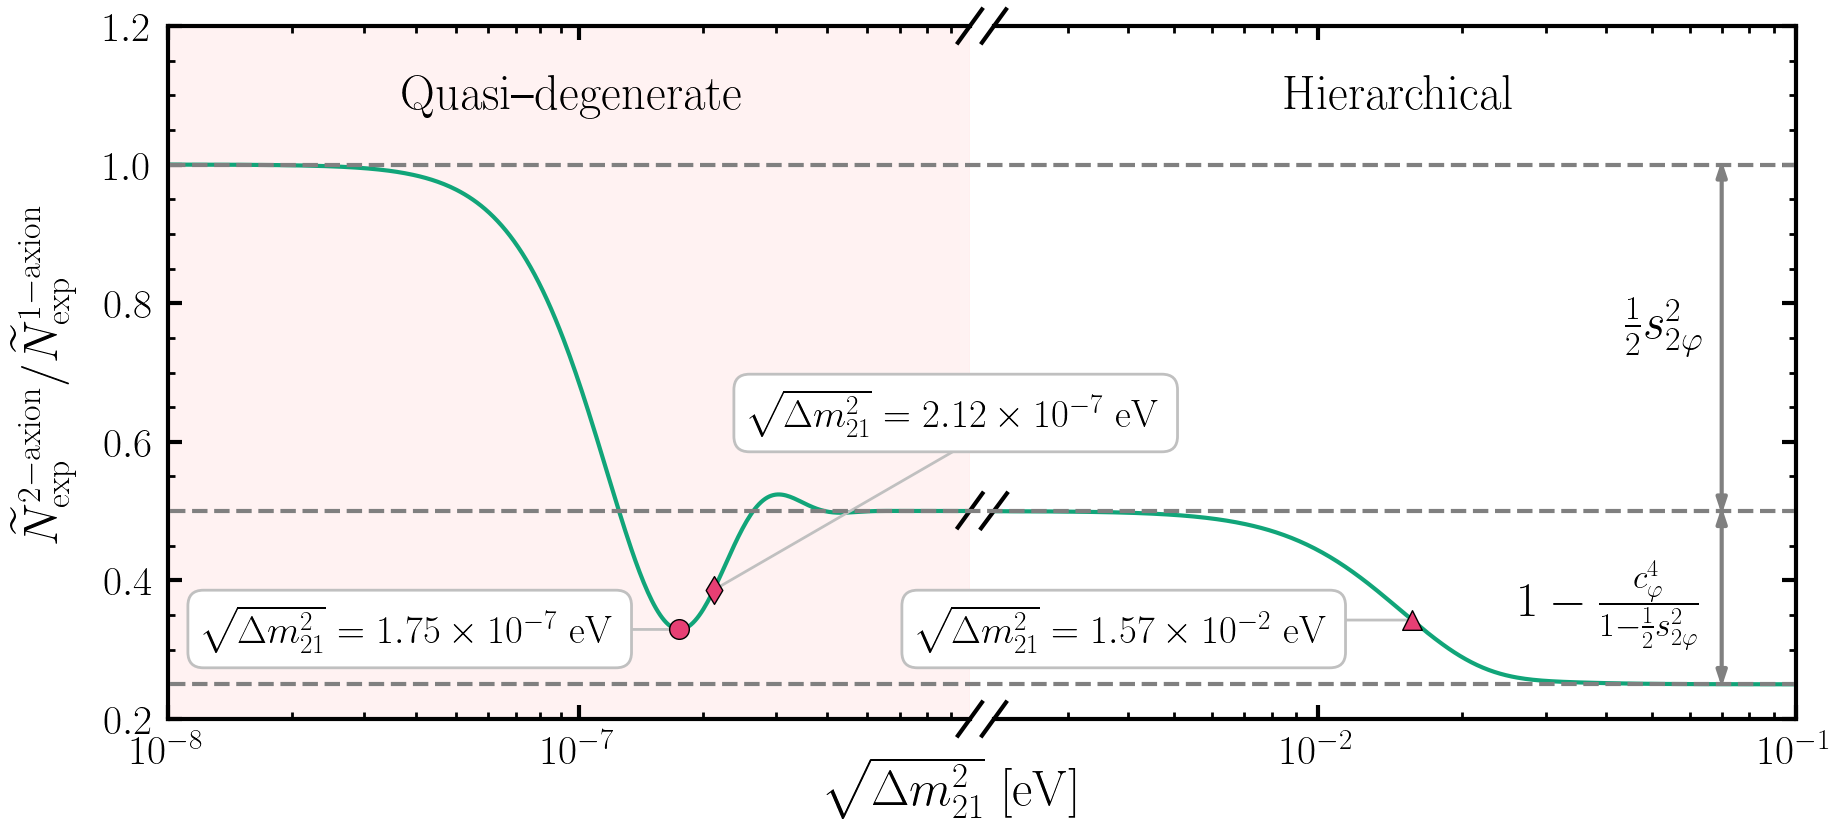

In [2]:
#%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.transforms as mtransforms
from matplotlib.lines import Line2D
from palettable.cartocolors.qualitative import Bold_10
from Functions_Binned_Analysis import BinnedPhotonNumber_Tilde, IAXO, L_ES
import os
os.environ['PATH'] = os.environ['PATH'] + ':/Library/TeX/texbin'

plt.rcParams.update({
   "text.usetex":True,
   "font.size":30,
   "axes.formatter.limits":[-3,3],
   "axes.linewidth":3,
   "lines.linewidth":3,
   "xtick.top":True,
   "xtick.bottom":True,
   "ytick.left":True,
   "ytick.right":True,
   "xtick.minor.visible":True,
   "ytick.minor.visible":True,
   "xtick.direction":"in",
   "ytick.direction":"in",
   "xtick.major.width":3,
   "xtick.minor.width":2,
   "ytick.major.width":3,
   "ytick.minor.width":2,
   "xtick.major.size":10,
   "xtick.minor.size":5,
   "ytick.major.size":10,
   "ytick.minor.size":5,
   "figure.figsize":[21,9],
   "savefig.dpi":300,
   "savefig.transparent":True
})

mixing = np.pi/4.0
L_source = L_ES
w_min = 0.0 # [keV]
w_max = 20.0 # [keV]
N_bins = 200
res_on = True
w_res = 100e-3 # [keV]

colors = Bold_10.mpl_colors

delta_m21_sq_vals_qd = np.logspace(-16.0,-6.0,1000)
x_qd = np.sqrt(delta_m21_sq_vals_qd)
delta_m21_sq_vals_h = np.logspace(-6.0,2.0,1000)
x_h = np.sqrt(delta_m21_sq_vals_h)
N_exp_tilde_total_qd = np.empty_like(delta_m21_sq_vals_qd,dtype=float)
N_exp_tilde_total_h = np.empty_like(delta_m21_sq_vals_h,dtype=float)

m2 = 1e-3 # [eV]
for k,dm2 in enumerate(delta_m21_sq_vals_qd):
    N_exp_tilde_total_qd[k] = np.sum(BinnedPhotonNumber_Tilde(m2,dm2,mixing,IAXO["B"],IAXO["L"],L_source,IAXO["S"],IAXO["t"],IAXO["eps_T"],IAXO["eps_D"],w_min,w_max,N_bins,res_on=res_on,w_res=w_res))

for k,dm2 in enumerate(delta_m21_sq_vals_h):
    m2 = (1+1e-10)*np.sqrt(dm2)
    N_exp_tilde_total_h[k] = np.sum(BinnedPhotonNumber_Tilde(m2,dm2,mixing,IAXO["B"],IAXO["L"],L_source,IAXO["S"],IAXO["t"],IAXO["eps_T"],IAXO["eps_D"],w_min,w_max,N_bins,res_on=res_on,w_res=w_res))

norm = N_exp_tilde_total_qd[0]
N_exp_tilde_total_qd = N_exp_tilde_total_qd/norm
N_exp_tilde_total_h = N_exp_tilde_total_h/norm

fig = plt.figure()
gs = gridspec.GridSpec(1,2,width_ratios=[1,1],wspace=0.03)
axL = fig.add_subplot(gs[0,0])
axR = fig.add_subplot(gs[0,1],sharey=axL)
axL.set_xscale("log")
axR.set_xscale("log")
axL.set_xlim(1e-8,8.9e-7)  
axR.set_xlim(2.1e-3,1e-1)
axL.set_ylim(0.2,1.2)
axR.set_ylim(0.2,1.2)
axL.tick_params(axis='x',which='major',pad=11)
axR.tick_params(axis='x',which='major',pad=11)
axL.tick_params(axis='y',which='major',pad=11)
axR.tick_params(axis='y',which='major',pad=11)
axL.tick_params(axis='y',which='both',right=False,labelright=False)
axR.tick_params(axis='y',which='both',left=False,labelleft=False)
axL.spines['right'].set_visible(False)
axR.spines['left'].set_visible(False)
plt.setp(axR.get_yticklabels(),visible=False)
fig.supxlabel(r"$\sqrt{\Delta m_{21}^2}\ [\mathrm{eV}]$",y=5e-10)
axL.set_ylabel(r"$\widetilde{N}_\mathrm{exp}^{2\mathrm{-axion}}/\widetilde{N}_\mathrm{exp}^{1\mathrm{-axion}}$",labelpad=20,fontsize=35)

# Break marks
d = 0.015
slope = 1.6 
axL.plot((1-d,1+d),(-d*slope,+d*slope),transform=axL.transAxes,color='k',clip_on=False,lw=3)
axL.plot((1-d,1+d),(1-d*slope,1+d*slope),transform=axL.transAxes,color='k',clip_on=False,lw=3)
axR.plot((-d,+d),(-d*slope,+d*slope),transform=axR.transAxes,color='k',clip_on=False,lw=3)
axR.plot((-d,+d),(1-d*slope,1+d*slope),transform=axR.transAxes,color='k',clip_on=False,lw=3)

def break_marks_data(ax,x0,y0,d=0.015,slope=1.6,lw=3,sep=2.2):
    f = 10**d
    x1,x2 = x0/f,x0*f
    yspan = ax.get_ylim()[1]-ax.get_ylim()[0]
    dy = d*slope*yspan
    delta = 0.5*sep*dy
    ax.plot([x1,x2],[y0-delta-dy,y0-delta+dy],color='k',lw=lw,clip_on=False)

break_marks_data(axL,x0=8.91e-7,y0=0.528,d=0.03,slope=0.82)
break_marks_data(axR,x0=2.1e-3,y0=0.528,d=0.027,slope=0.93)

# N_exp_total
axL.plot(x_qd,N_exp_tilde_total_qd,color=colors[1])
axR.plot(x_h,N_exp_tilde_total_h,color=colors[1])

# Horizontal lines
trans = axL.transData.transform
inv = fig.transFigure.inverted().transform
y1_display = trans((0,1))[1]
y1_fig = inv((0,y1_display))[1]
line1 = Line2D([0.126,0.899],[y1_fig,y1_fig],transform=fig.transFigure,color='gray',linestyle='--',lw=3)
trans = axL.transData.transform
inv = fig.transFigure.inverted().transform
y2_display = trans((0,0.5))[1]
y2_fig = inv((0,y2_display))[1]
line2 = Line2D([0.126,0.899],[y2_fig,y2_fig],transform=fig.transFigure,color='gray',linestyle='--',lw=3)
trans = axL.transData.transform
inv = fig.transFigure.inverted().transform
y3_display = trans((0,0.25))[1]
y3_fig = inv((0,y3_display))[1]
line3 = Line2D([0.126,0.899],[y3_fig,y3_fig],transform=fig.transFigure,color='gray',linestyle='--',lw=3)
fig.add_artist(line1)
fig.add_artist(line2)
fig.add_artist(line3)

# Arrows and equations
axR.annotate("",xy=(7e-2,1.01),xytext=(7e-2,0.491),arrowprops=dict(arrowstyle='<|-|>,head_length=0.3,head_width=0.1',color='gray',linewidth=3))
axR.annotate("",xy=(7e-2,0.51),xytext=(7e-2,0.242),arrowprops=dict(arrowstyle='<|-|>,head_length=0.3,head_width=0.1',color='gray',linewidth=3))
axR.text(4.4e-2,0.75,r'$\frac{1}{2}s_{2\varphi}^2$',fontsize=35)
axR.text(2.65e-2,0.35,r'$1-\frac{c_\varphi^4}{1-\frac{1}{2}s_{2\varphi}^2}$',fontsize=35)

# Relevant points
x1 = 1.75e-7# [eV]
idx_x1 = np.argmin(np.abs(np.sqrt(delta_m21_sq_vals_qd)-x1))
x1_val = np.sqrt(delta_m21_sq_vals_qd[idx_x1])
y1_val = N_exp_tilde_total_qd[idx_x1]
axL.scatter(x1_val,y1_val,color=colors[4],s=200,zorder=5,marker='o',edgecolor='black',label=r'$\sqrt{\Delta m_{21}^2}=1.75\times 10^{-7}\ \mathrm{eV}$')
fig.text(0.24,0.21,r"$\sqrt{\Delta m_{21}^2} = 1.75\times 10^{-7}\ \mathrm{eV}$",ha="center",va="center",fontsize=28,bbox=dict(boxstyle="round",facecolor="white",edgecolor="silver",pad=0.4,lw=2))
axL.annotate("",xy=(x1_val,y1_val),xytext=(8.58e-8,y1_val),arrowprops=dict(arrowstyle='-',color='silver',linewidth=2))

x2 = 2.12e-7 # [eV]
idx_x2 = np.argmin(np.abs(np.sqrt(delta_m21_sq_vals_qd)-x2))
x2_val = np.sqrt(delta_m21_sq_vals_qd[idx_x2])
y2_val = N_exp_tilde_total_qd[idx_x2]
axL.scatter(x2_val,y2_val,color=colors[4],s=200,zorder=5,marker='d',edgecolor='black',label=r'$\sqrt{\Delta m_{21}^2}=2.12\times 10^{-7}\ \mathrm{eV}$')
fig.text(0.5,0.45,r"$\sqrt{\Delta m_{21}^2} = 2.12\times 10^{-7}\ \mathrm{eV}$",ha="center",va="center",fontsize=28,bbox=dict(boxstyle="round",facecolor="white",edgecolor="silver",pad=0.4,lw=2))
axL.annotate("",xy=(x2_val,y2_val),xytext=(8.9e-7,0.6),arrowprops=dict(arrowstyle='-',color='silver',linewidth=2))

x3 = 1.57e-2# [eV]
idx_x3 = np.argmin(np.abs(np.sqrt(delta_m21_sq_vals_h)-x3))
x3_val = np.sqrt(delta_m21_sq_vals_h[idx_x3])
y3_val = N_exp_tilde_total_h[idx_x3]
axR.scatter(x3_val,y3_val,color=colors[4],s=200,zorder=5,marker='^',edgecolor='black',label=r'$\sqrt{\Delta m_{21}^2}=1.57\times 10^{-2}\ \mathrm{eV}$')
fig.text(0.58,0.21,r"$\sqrt{\Delta m_{21}^2} = 1.57\times 10^{-2}\ \mathrm{eV}$",ha="center",va="center",fontsize=28,bbox=dict(boxstyle="round",facecolor="white",edgecolor="silver",pad=0.4,lw=2))
axR.annotate("",xy=(x3_val,y3_val),xytext=(1.09e-2,y3_val),arrowprops=dict(arrowstyle='-',color='silver',linewidth=2))

# Regions
axL.text(3.7e-8,1.08,r'$\mathrm{Quasi}$--$\mathrm{degenerate}$',fontsize=35)
axR.text(8.5e-3,1.08,r'$\mathrm{Hierarchical}$',fontsize=35)
axL.axvspan(1e-8,8.9e-7,color="red",alpha=0.05)

fig.savefig("plots/Nexp_evolution.pdf",bbox_inches="tight")
fig.savefig("plots/Nexp_evolution.png",bbox_inches="tight")
plt.show()